In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report

pd.options.display.max_columns = None

In [2]:
train_base = pd.read_csv("./sign/sign_mnist_train.csv")
test_base = pd.read_csv("./sign/sign_mnist_test.csv")

In [3]:
# trainとtestでcsvが用意されていたのでそれを目的変数yと説明変数Xに分割
y_train = train_base['label'].values
X_train = train_base.drop(columns='label').values.reshape(len(train_base), 28,28,1)
y_test = test_base['label'].values
X_test = test_base.drop(columns='label').values.reshape(len(test_base), 28,28,1)

# 検証データを用意(割合はtestデータと同じ)
size = len(test_base) / (len(train_base) + len(test_base))
X_train, X_valid, y_train, y_valid = train_test_split(X_train, y_train, test_size=size, random_state=0)

In [4]:
# One-hotエンコード
y_train = tf.one_hot(y_train, 25)
y_valid = tf.one_hot(y_valid, 25)
y_test = tf.one_hot(y_test, 25)

# データの確認
print(f"y_train={y_train.shape}, y_valid={y_valid.shape}, y_test={y_test.shape}")
print(f"X_train={X_train.shape}, X_valid={X_valid.shape}, X_test={X_test.shape}")

y_train=(21768, 25), y_valid=(5687, 25), y_test=(7172, 25)
X_train=(21768, 28, 28, 1), X_valid=(5687, 28, 28, 1), X_test=(7172, 28, 28, 1)


In [5]:
inputs = tf.keras.Input(shape=(28, 28, 1))

# 96x96x3にリサイズ & RGB化
x = tf.keras.layers.Resizing(96, 96)(inputs)
x = tf.keras.layers.Lambda(lambda t: tf.image.grayscale_to_rgb(t))(x) 

# MobileNetV3 の前処理（[-1, 1]へスケーリング）
x = tf.keras.layers.Lambda(tf.keras.applications.mobilenet_v3.preprocess_input)(x)

# 事前学習済みベース（トップなし、グローバルプーリング）
base = tf.keras.applications.MobileNetV3Small(
    include_top=False,
    weights='imagenet',
    input_tensor=x,
    pooling='avg'
)
# 転移学習の前半はベースを凍結
base.trainable = False

# 追加の分類ヘッド
h = tf.keras.layers.Dropout(0.3)(base.output)
h = tf.keras.layers.Dense(64, activation='relu', kernel_regularizer=tf.keras.regularizers.l2(1e-4))(h)
h = tf.keras.layers.Dropout(0.4)(h)
outputs = tf.keras.layers.Dense(25, activation='softmax')(h)

model = tf.keras.models.Model(inputs=inputs, outputs=outputs)

# モデルの構築
model.compile(optimizer = "adam", loss="categorical_crossentropy", metrics=['accuracy'])

c:\Users\1004360\Desktop\LLM\aidev\.venv\Lib\site-packages\keras\src\applications\mobilenet_v3.py:452: UserWarning: `input_shape` is undefined or non-square, or `rows` is not 224. Weights for input shape (224, 224) will be loaded as the default.
  return MobileNetV3(


4334752/4334752 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [6]:
%%time
# 学習の実施
log = model.fit(X_train, y_train, epochs=100, batch_size=32, verbose=True,
                callbacks=[tf.keras.callbacks.EarlyStopping(monitor='val_loss', min_delta=0, patience=50, verbose=1)],
                validation_data=(X_valid, y_valid))


Epoch 1/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 21s 28ms/step - accuracy: 0.5553 - loss: 1.4459 - val_accuracy: 0.9492 - val_loss: 0.2985
Epoch 2/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.8235 - loss: 0.5584 - val_accuracy: 0.9851 - val_loss: 0.1542
Epoch 3/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 26ms/step - accuracy: 0.8769 - loss: 0.3996 - val_accuracy: 0.9887 - val_loss: 0.1106
Epoch 4/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9018 - loss: 0.3344 - val_accuracy: 0.9954 - val_loss: 0.0882
Epoch 5/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9151 - loss: 0.2974 - val_accuracy: 0.9968 - val_loss: 0.0749
Epoch 6/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 19s 27ms/step - accuracy: 0.9228 - loss: 0.2742 - val_accuracy: 0.9986 - val_loss: 0.0715
Epoch 7/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9265 - loss: 0.2656 - val_accuracy: 0.9979 - val_loss: 0.0686
Epoch 8/100
681/681 ━━━━━━━━━━━━━━━━━━━━ 18s 27ms/step - accuracy: 0.9339 - loss: 0

Text(0, 0.5, 'crossentropy')

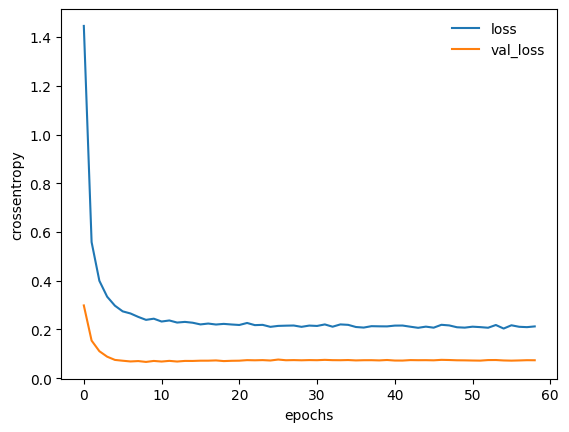

In [7]:
plt.plot(log.history['loss'], label='loss')
plt.plot(log.history['val_loss'], label='val_loss')
plt.legend(frameon=False)
plt.xlabel("epochs")
plt.ylabel("crossentropy")

In [8]:
y_pred = np.argmax(model.predict(X_test), axis=1)
y_test_ = np.argmax(y_test, axis=1)
print(classification_report(y_test_, y_pred))

225/225 ━━━━━━━━━━━━━━━━━━━━ 6s 24ms/step
              precision    recall  f1-score   support

           0       1.00      1.00      1.00       331
           1       1.00      0.95      0.98       432
           2       1.00      0.99      1.00       310
           3       0.94      1.00      0.97       245
           4       1.00      0.98      0.99       498
           5       1.00      1.00      1.00       247
           6       0.99      0.95      0.97       348
           7       0.99      0.98      0.99       436
           8       0.99      1.00      0.99       288
          10       0.99      0.88      0.93       331
          11       1.00      1.00      1.00       209
          12       0.96      0.92      0.94       394
          13       0.98      0.88      0.93       291
          14       0.99      1.00      1.00       246
          15       1.00      1.00      1.00       347
          16       1.00      1.00      1.00       164
          17       0.88      0.99      